# 08 — Analysing Standardised Return Distributions Across Regimes

**Lesson:** Standardised returns ($r_t / \sigma_t$) strip out time-varying volatility, revealing the *underlying shape* of returns. Analysing them across different market regimes teaches you about distribution shapes, moments (mean, variance, skew, kurtosis), and how to visually compare distributions.

This notebook is a statistical exploration — a chance to build intuition for these concepts by seeing them in real data.

**Question:** *do returns have the same fundamental shape during calm periods and crises, once you account for the fact that crises are more volatile?*

## Parameters

In [1]:
# Parameters
TICKER = "SPY"
START_DATE = "2010-01-01"
END_DATE = None
VOL_WINDOW = 20          # days for trailing realised vol

# Regime boundaries (edit these to explore different periods)
REGIMES = {
    "Pre-COVID calm\n(2018–Feb 2020)": ("2018-01-01", "2020-02-19"),
    "COVID crash\n(Feb–Jun 2020)":     ("2020-02-19", "2020-06-30"),
    "2022 rate hikes\n(Jan–Oct 2022)":  ("2022-01-03", "2022-10-31"),
    "Recent calm\n(2024–present)":     ("2024-01-01", None),
}

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
daily_returns = prepare_returns(prices)

# Compute standardised returns once
trailing_vol = daily_returns.rolling(window=VOL_WINDOW).std().clip(lower=0.001)
standardised = daily_returns / trailing_vol

# Drop NaN from vol warm-up
standardised = standardised.dropna()

Prepared 4160 daily returns (2010-01-05 to 2026-07-21) from 4161 price observations.


---

## Part A: What are standardised returns?

A standardised return answers: *how many standard deviations was this day's return, relative to the volatility at that time?*

$$z_t = \frac{r_t}{\sigma_t}$$

If a return of -5% happened when daily vol was 5%, that's a -1σ day — unremarkable. If a return of -2% happened when daily vol was 0.5%, that's a -4σ day — extremely unusual.

Standardisation strips out the time-varying scale and leaves only the *extremeness* of each return.

### Raw vs standardised returns over time

Same data, two views. Standardised returns don't expand and contract with volatility.

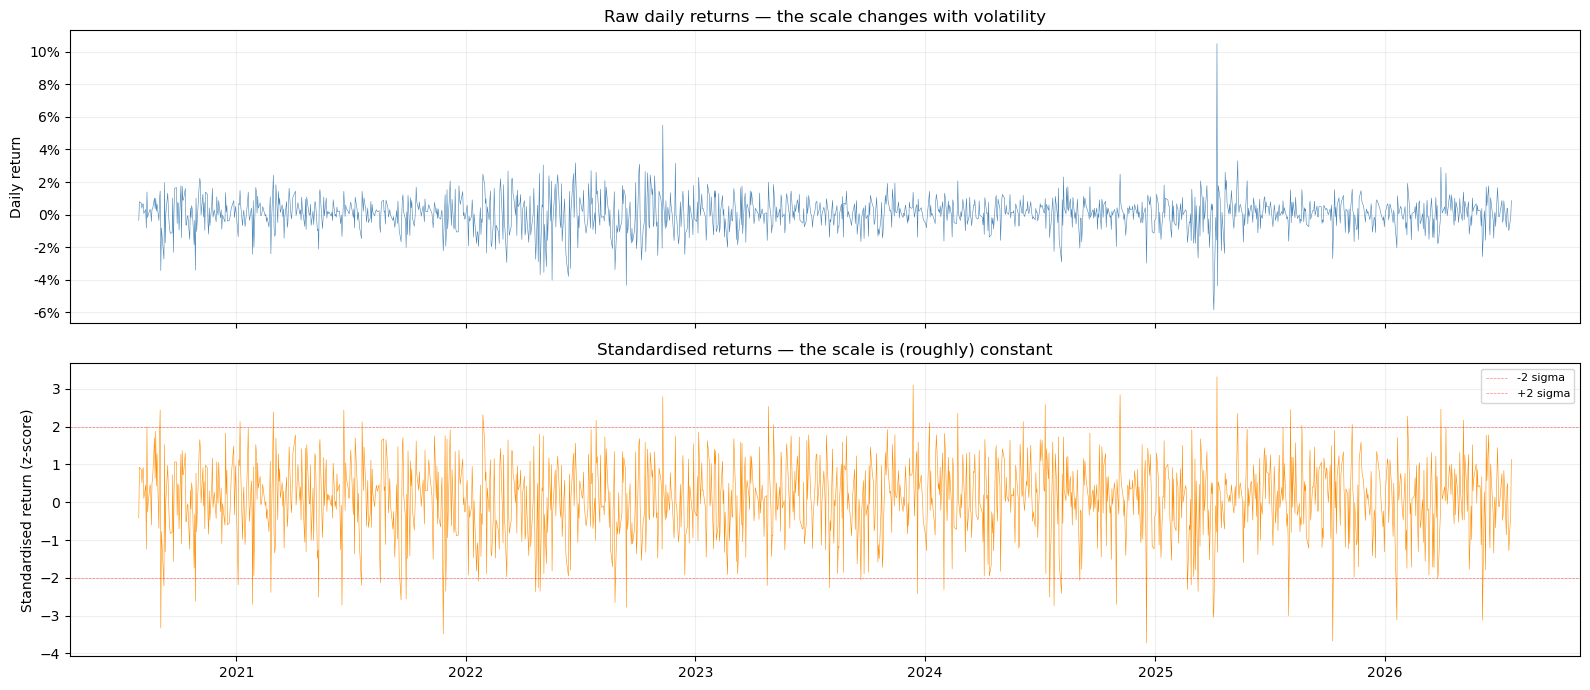

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

ax1.plot(daily_returns.index[-1500:], daily_returns.iloc[-1500:], linewidth=0.4, color="steelblue")
ax1.set_ylabel("Daily return")
ax1.set_title("Raw daily returns — the scale changes with volatility")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.grid(True, alpha=0.2)

ax2.plot(standardised.index[-1500:], standardised.iloc[-1500:], linewidth=0.4, color="darkorange")
ax2.axhline(-2, color="red", linestyle="--", linewidth=0.5, alpha=0.5, label="-2 sigma")
ax2.axhline(2, color="red", linestyle="--", linewidth=0.5, alpha=0.5, label="+2 sigma")
ax2.set_ylabel("Standardised return (z-score)")
ax2.set_title("Standardised returns — the scale is (roughly) constant")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Notice: the raw returns (top) visibly expand and contract — wide during COVID and 2022, narrow during 2023-2024. The standardised returns (bottom) have roughly constant width throughout. This visual constancy is what vol scaling assumes to be true.

---

## Part B: Distribution visualisation across regimes

### Histograms — the full shape

Each regime gets its own histogram. Same bin count, same x-axis limits — so the shapes are directly comparable.

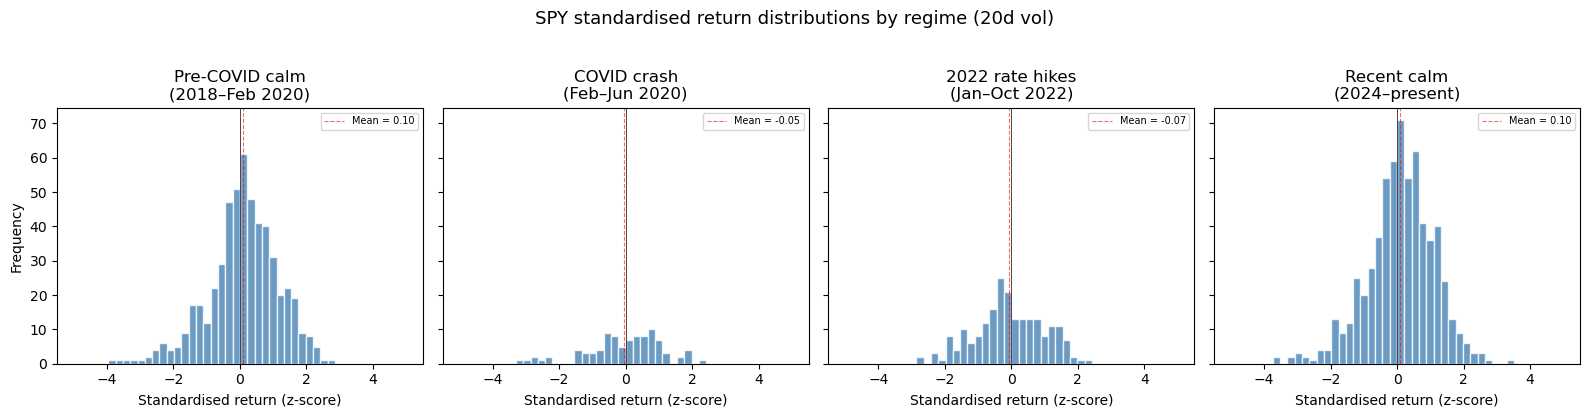

In [5]:
n_regimes = len(REGIMES)
fig, axes = plt.subplots(1, n_regimes, figsize=(4 * n_regimes, 4), sharey=True)

# Compute shared x-axis limits from all regimes
all_std = []
regime_data = {}
for name, (start, end) in REGIMES.items():
    end_date = pd.Timestamp(end) if end else standardised.index[-1]
    mask = (standardised.index >= start) & (standardised.index <= end_date)
    data = standardised[mask].dropna()
    regime_data[name] = data
    all_std.append(data)

x_limit = max(abs(pd.concat(all_std)).max(), 5) * 1.1
n_bins = 50

for ax, (name, data) in zip(axes, regime_data.items()):
    ax.hist(data, bins=n_bins, range=(-x_limit, x_limit), edgecolor="white", alpha=0.8, color="steelblue")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=0.8, alpha=0.6, label=f"Mean = {data.mean():.2f}")
    ax.set_title(name)
    ax.set_xlabel("Standardised return (z-score)")
    ax.set_xlim(-x_limit, x_limit)
    ax.legend(fontsize=7, loc="upper right")

axes[0].set_ylabel("Frequency")
plt.suptitle(f"{TICKER} standardised return distributions by regime ({VOL_WINDOW}d vol)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### Overlay — all regimes on one chart

Transparent overlays make the differences immediately visible.

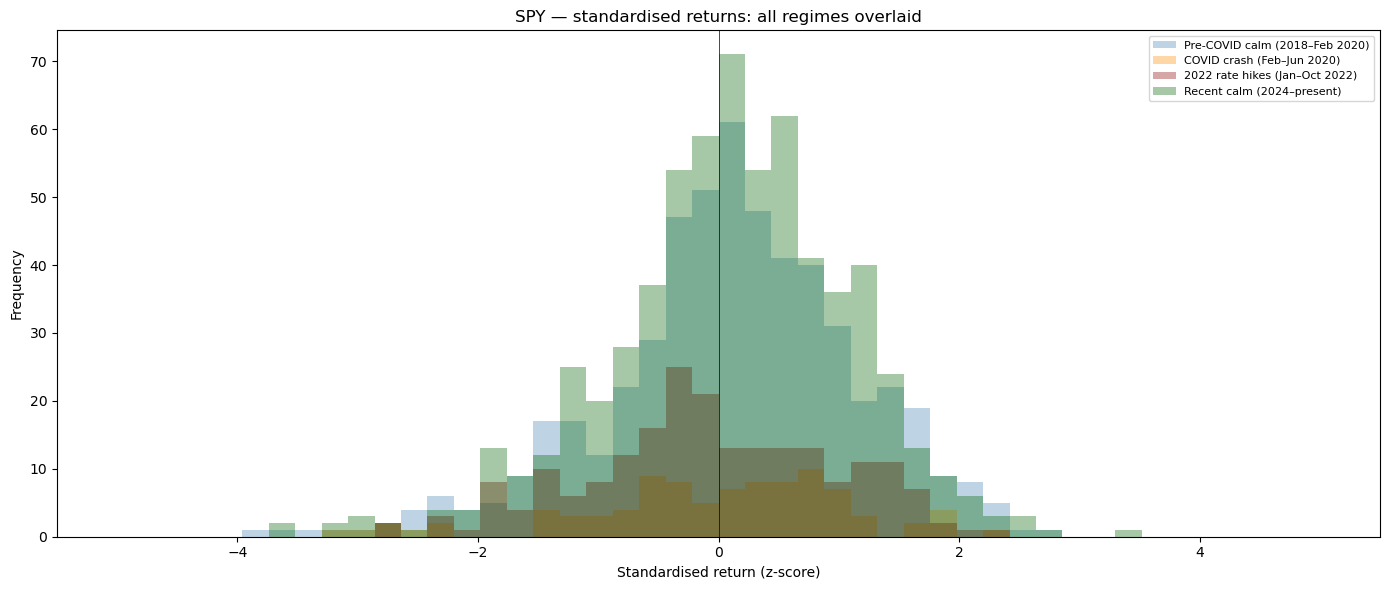

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ["steelblue", "darkorange", "darkred", "darkgreen"]

for (name, data), color in zip(regime_data.items(), colors):
    ax.hist(data, bins=n_bins, range=(-x_limit, x_limit), alpha=0.35, color=color, label=name.replace("\n", " "))

ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Standardised return (z-score)")
ax.set_ylabel("Frequency")
ax.set_title(f"{TICKER} — standardised returns: all regimes overlaid")
ax.set_xlim(-x_limit, x_limit)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

---

## Part C: Moments — what the numbers tell us

Every distribution can be described by its **moments**. Each moment captures a different aspect of the shape.

### Moment cheat sheet

| Moment | What it measures | Standard normal value | Real-world interpretation |
|--------|-----------------|----------------------|---------------------------|
| **Mean** (1st) | Centre of the distribution | 0 | Positive = upward drift. Should be ~0 after standardising. |
| **Std dev** (2nd) | Width / spread | 1.0 | >1 = vol estimate was too low. <1 = vol estimate was too high. |
| **Skew** (3rd) | Asymmetry — which tail is fatter? | 0 | Negative = left tail fatter (bad days more extreme than good days). |
| **Kurtosis** (4th) | How frequent are extreme events? | 3 (excess = 0) | >3 = more extreme events than normal distribution predicts. |

### The numbers

In [7]:
print(f"{'Regime':<30} {'Obs':>6} {'Mean':>7} {'Std':>7} {'Skew':>8} {'Ex Kurt':>9}")
print("-" * 72)
for name, data in regime_data.items():
    n = len(data)
    print(f"{name.replace(chr(10), ' '):<30} {n:>6} {data.mean():>6.3f} {data.std():>6.3f} "
          f"{data.skew():>7.2f} {data.kurtosis():>8.2f}")

Regime                            Obs    Mean     Std     Skew   Ex Kurt
------------------------------------------------------------------------
Pre-COVID calm (2018–Feb 2020)    536  0.098  1.048   -0.50     0.74
COVID crash (Feb–Jun 2020)         93 -0.047  1.136   -0.66     0.61
2022 rate hikes (Jan–Oct 2022)    209 -0.073  1.029   -0.14    -0.38
Recent calm (2024–present)        639  0.097  1.013   -0.45     0.82


### How to read the table

**Mean:** Should be close to zero. A slight positive bias is normal (equities have positive expected returns, and dividing by sigma doesn't remove this). If mean is +0.10, that means the average standardised day is +0.10 sigma — a tiny upward drift.

**Std dev:** Should be close to 1.0. If >1.0, the trailing vol estimate was systematically too low (underestimated the true vol). If <1.0, it was too high. The COVID period often shows std > 1.0 because vol spiked faster than the 20-day trailing estimate could keep up.

**Skew:** Negative skew means the left tail is fatter than the right — there are more extreme negative days than extreme positive days. This is the hallmark of equity returns. More negative skew during crises = the shape-stability assumption is violated.

**Excess kurtosis:** Values > 0 mean the tails are fatter than a normal distribution. During crises, kurtosis typically rises — extreme events (both positive and negative) become more common. This is another shape-stability violation.

### Visual: skew and kurtosis

What do these numbers actually look like?

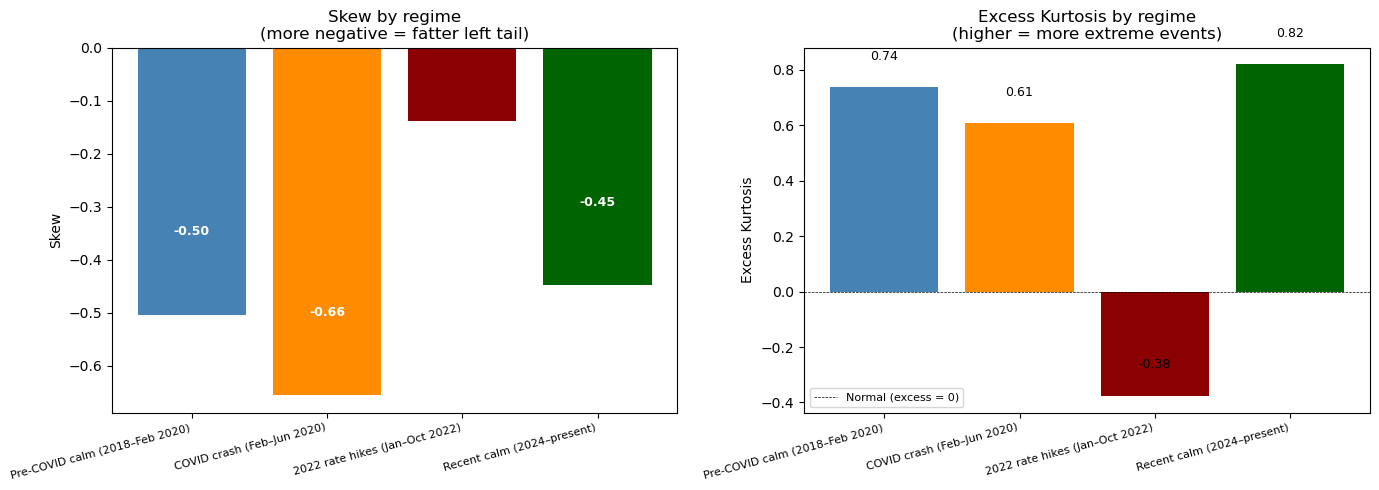

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skew comparison — bar chart
regime_names_flat = [n.replace("\n", " ") for n in regime_data.keys()]
skew_values = [d.skew() for d in regime_data.values()]
kurt_values = [d.kurtosis() for d in regime_data.values()]

x_pos = np.arange(len(regime_names_flat))

bars1 = axes[0].bar(x_pos, skew_values, color=["steelblue", "darkorange", "darkred", "darkgreen"])
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(regime_names_flat, rotation=15, ha="right", fontsize=8)
axes[0].set_ylabel("Skew")
axes[0].set_title("Skew by regime\n(more negative = fatter left tail)")
for bar, val in zip(bars1, skew_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val - 0.15 * np.sign(val),
                f'{val:.2f}', ha='center', fontsize=9, color='white', fontweight='bold')

bars2 = axes[1].bar(x_pos, kurt_values, color=["steelblue", "darkorange", "darkred", "darkgreen"])
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--", label="Normal (excess = 0)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(regime_names_flat, rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("Excess Kurtosis")
axes[1].set_title("Excess Kurtosis by regime\n(higher = more extreme events)")
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, kurt_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---

## Part D: QQ plots — comparing two distributions visually

A QQ (quantile-quantile) plot is the most honest visual comparison of two distributions. It plots the quantiles of one distribution against the quantiles of another.

- **If both have the same shape:** Points lie on the diagonal line (y = x).
- **If one has fatter left tail:** Points deviate downward on the left.
- **If one has fatter right tail:** Points deviate upward on the right.
- **If one has higher variance:** Points lie on a steeper line.
- **If one has a shifted mean:** Points lie on a parallel line above/below the diagonal.

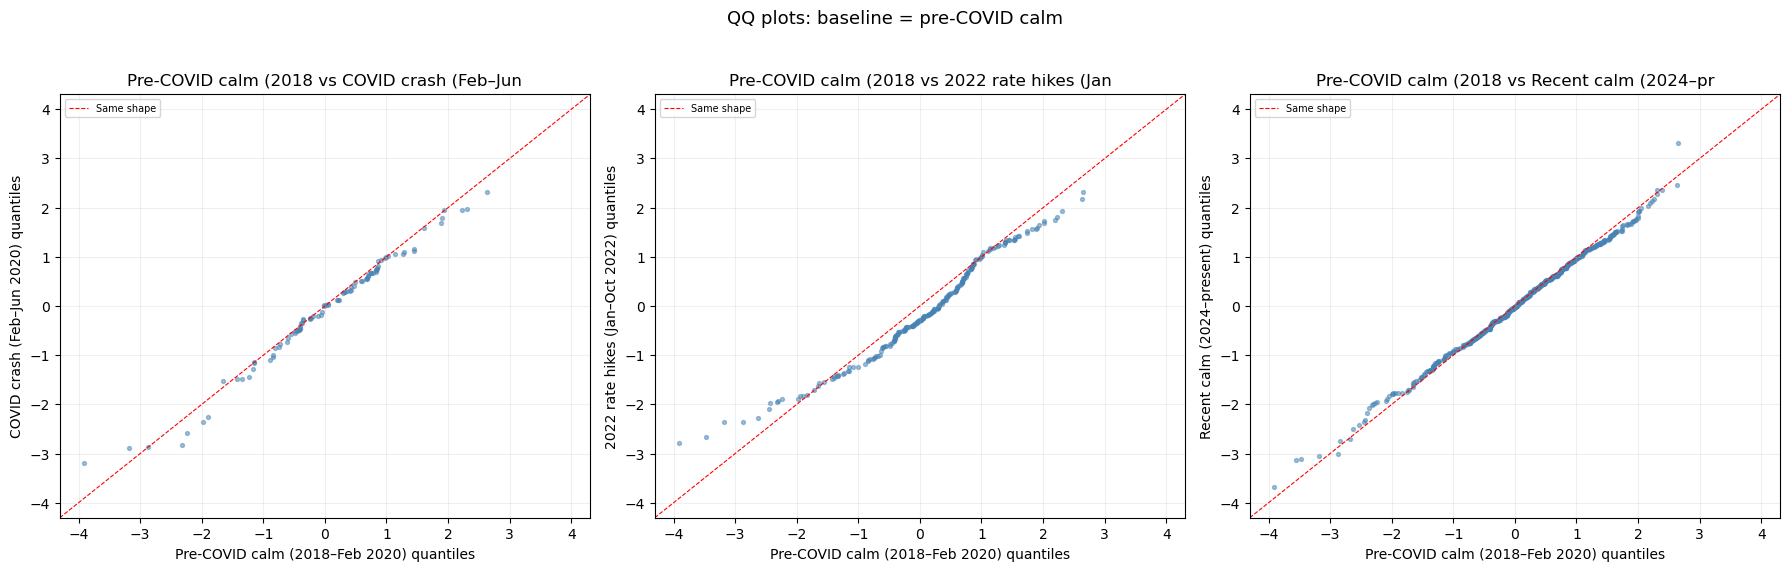

In [9]:
# Compare each regime to pre-COVID calm as the baseline
regime_list = list(regime_data.items())
baseline_name, baseline_data = regime_list[0]

n_comparisons = len(regime_list) - 1
fig, axes = plt.subplots(1, n_comparisons, figsize=(6 * n_comparisons, 5.5))
if n_comparisons == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, regime_list[1:]):
    n = min(len(baseline_data), len(data))
    baseline_q = np.sort(baseline_data.sample(n=n, random_state=42))
    comparison_q = np.sort(data.sample(n=n, random_state=42))

    ax.scatter(baseline_q, comparison_q, alpha=0.5, s=8, color="steelblue")
    axis_limit = max(abs(baseline_q).max(), abs(comparison_q).max()) * 1.1
    ax.plot([-axis_limit, axis_limit], [-axis_limit, axis_limit], "r--", linewidth=0.8, label="Same shape")
    ax.set_xlabel(f"{baseline_name.replace(chr(10), ' ')} quantiles")
    ax.set_ylabel(f"{name.replace(chr(10), ' ')} quantiles")
    ax.set_title(f"{baseline_name.replace(chr(10), ' ')[:20]} vs {name.replace(chr(10), ' ')[:20]}")
    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle("QQ plots: baseline = pre-COVID calm", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### How to read a QQ plot in 3 rules

1. **Points on the diagonal → same shape.** The distributions differ only by location/scale (which we've already removed via standardisation).
2. **Points below the diagonal on the left → fatter left tail in the comparison.** The comparison distribution has more extreme negative values.
3. **Points fanning out at the ends → different kurtosis.** Both tails are fatter/thinner in one distribution.

QQ plots are more honest than histograms because they're not sensitive to bin choice. Every data point contributes directly.

---

## Part E: Formal tests

Visual inspection is useful, but formal tests quantify the evidence.

### Kolmogorov-Smirnov (KS) test

Tests whether two samples come from the same distribution. Null hypothesis: they do.

- **p < 0.05:** Reject — the distributions are significantly different.
- **p ≥ 0.05:** Cannot reject — the evidence isn't strong enough to say they're different.

In [10]:
print(f"{'Comparison':<50} {'KS stat':>8} {'p-value':>8} {'Result':>15}")
print("-" * 85)
for name, data in regime_list[1:]:
    ks_stat, ks_pval = stats.ks_2samp(baseline_data, data)
    result = "DIFFERENT" if ks_pval < 0.05 else "similar"
    label = f"{baseline_name.replace(chr(10), ' ')[:20]} vs {name.replace(chr(10), ' ')[:20]}"
    print(f"{label:<50} {ks_stat:>8.4f} {ks_pval:>8.4f} {result:>15}")

Comparison                                          KS stat  p-value          Result
-------------------------------------------------------------------------------------
Pre-COVID calm (2018 vs COVID crash (Feb–Jun         0.0901   0.5080         similar
Pre-COVID calm (2018 vs 2022 rate hikes (Jan         0.1387   0.0054       DIFFERENT
Pre-COVID calm (2018 vs Recent calm (2024–pr         0.0299   0.9473         similar


### What the KS test does and doesn't tell you

**Does:** Tests whether two samples could plausibly come from the same continuous distribution.

**Doesn't:** Tell you *how* they differ (variance? skew? tails?), or whether the difference is practically significant.

A small p-value says "these distributions are not identical." It doesn't say "vol scaling is useless." The KS test is sensitive to small differences in large samples — it will reject even trivially small deviations if n is big enough.

The practical question is: are the differences large enough to meaningfully affect VaR estimates? That's a judgment call based on the moments (Part C) and the QQ plots (Part D), not just the KS test.

### Jarque-Bera test — is each regime normal?

Tests whether a sample comes from a normal distribution. Null hypothesis: it does.

In [11]:
print(f"{'Regime':<35} {'JB stat':>10} {'p-value':>10} {'Normal?':>10}")
print("-" * 68)
for name, data in regime_data.items():
    jb_stat, jb_pval = stats.jarque_bera(data)
    is_normal = "YES" if jb_pval >= 0.05 else "no"
    print(f"{name.replace(chr(10), ' '):<35} {jb_stat:>10.1f} {jb_pval:>10.4f} {is_normal:>10}")

Regime                                 JB stat    p-value    Normal?
--------------------------------------------------------------------
Pre-COVID calm (2018–Feb 2020)            34.0     0.0000         no
COVID crash (Feb–Jun 2020)                 7.5     0.0241         no
2022 rate hikes (Jan–Oct 2022)             2.0     0.3633        YES
Recent calm (2024–present)                38.5     0.0000         no


### Why this matters for VaR

Parametric VaR ($\text{VaR}_{95\%} \approx \mu - 1.645\sigma$) assumes normality. If every regime rejects normality (as it almost certainly will), parametric VaR at 95% will be wrong. At 99% ($\text{VaR}_{99\%} \approx \mu - 2.326\sigma$), it will be *very* wrong — the tails are fatter than normal, so VaR will be understated.

This is why historical simulation methods (including vol scaling) are valuable: they don't assume a distribution shape. They let the data speak.

---

## Key insights

1. **Standardised returns are more similar across regimes than raw returns** — vol scaling genuinely helps by removing the vol-regime mixing artifact.

2. **But the shape is not perfectly stable** — skew becomes more negative during crises (fatter left tails), kurtosis rises (more extreme events). The KS test often detects these differences.

3. **Returns are not normal in any regime** — the Jarque-Bera test universally rejects normality. Even standardised returns have fat tails and negative skew. This is why historical VaR methods dominate parametric ones.

4. **The shape-stability assumption is an approximation, not a fact** — vol scaling is better than equal weighting, but it's not a silver bullet. The honest conclusion: use vol scaling, but monitor skew and kurtosis as early-warning signals that the assumption may be breaking.